### data processing 
1. vector clipping for river and lake data.  


In [ ]:
import geopandas as gpd 
import cartopy.crs as ccrs
import matplotlib.pyplot as plt


In [ ]:
path_ygp = 'data/boundary/ygp_region_v2.gpkg'
path_river_wide = 'data/river/sword_reaches_ygp_wide.gpkg'
path_lake_wide = 'data/lakes_ygp/HydroLAKES_ygp_wide.gpkg'
path_basin_l04_wide = 'data/boundary/hydro_basin_lev04_ygp_wide.gpkg'
path_basin_l05_wide = 'data/boundary/hydro_basin_lev05_ygp_wide.gpkg' 


In [ ]:
ygp_vec_gdf = gpd.read_file(path_ygp)
river_wide_gdf = gpd.read_file(path_river_wide)
lake_wide_gdf = gpd.read_file(path_lake_wide)
basin_l04_wide_gdf = gpd.read_file(path_basin_l04_wide)
basin_l05_wide_gdf = gpd.read_file(path_basin_l05_wide)


<GeoAxes: >

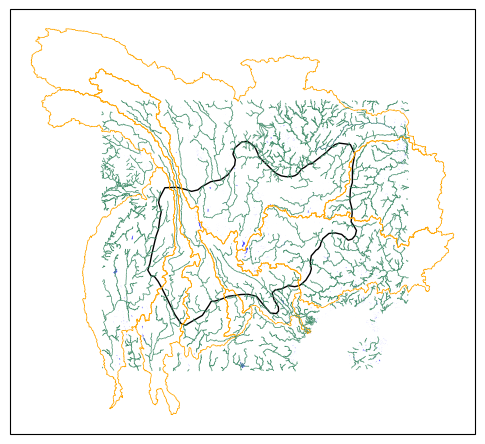

In [46]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ygp_vec_gdf.plot(facecolor='none', edgecolor='black', ax=ax)
river_wide_gdf.plot(color="#428D6B" , linewidth=0.5, ax=ax) 
lake_wide_gdf.plot(color='blue', alpha=0.7, ax=ax) 
basin_l04_wide_gdf.plot(facecolor='none', edgecolor='orange', linewidth=0.5, ax=ax) 
# basin_l05_wide_gdf.plot(facecolor='none', edgecolor='red', linewidth=0.5, ax=ax) 

2. clipping

In [49]:
path_river_ygp = 'data/river/sword_reaches_ygp_clip.gpkg'
path_lake_ygp = 'data/lakes_ygp/HydroLAKES_ygp_clip.gpkg'
path_basin_l04_ygp = 'data/boundary/hydro_basin_lev04_ygp_clip.gpkg'
path_basin_l05_ygp = 'data/boundary/hydro_basin_lev05_ygp_clip.gpkg'


In [50]:
river_ygp_gdf = river_wide_gdf.clip(ygp_vec_gdf)
lake_ygp_gdf = lake_wide_gdf.clip(ygp_vec_gdf)
basin_l04_ygp_gdf = basin_l04_wide_gdf.clip(ygp_vec_gdf)
basin_l05_ygp_gdf = basin_l05_wide_gdf.clip(ygp_vec_gdf) 


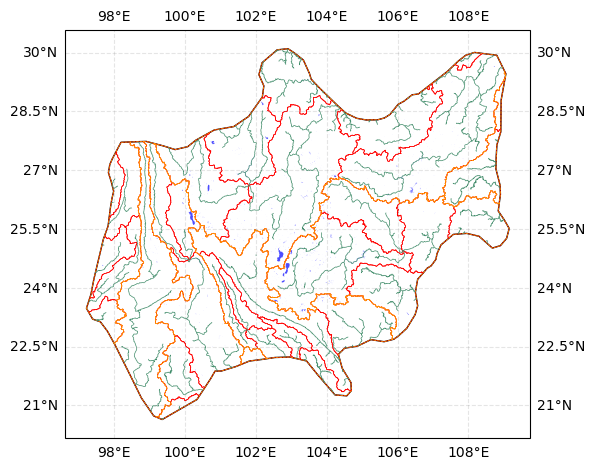

In [47]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ygp_vec_gdf.plot(facecolor='none', edgecolor='black', ax=ax)
river_ygp_gdf.plot(color="#428D6B" , linewidth=0.5, ax=ax)
lake_ygp_gdf.plot(color='blue', alpha=0.7, ax=ax)
basin_l05_ygp_gdf.plot(facecolor='none', edgecolor='red', linewidth=0.5, ax=ax)
basin_l04_ygp_gdf.plot(facecolor='none', edgecolor='orange', linestyle='--', linewidth=0.5, ax=ax)
ax.gridlines(draw_labels=True, alpha=0.2, linestyle='--', color='gray')  


In [ ]:
## save the clipped vector data
river_ygp_gdf.to_file(path_river_ygp, driver='GPKG')
lake_ygp_gdf.to_file(path_lake_ygp, driver='GPKG')
basin_l04_ygp_gdf.to_file(path_basin_l04_ygp, driver='GPKG')
basin_l05_ygp_gdf.to_file(path_basin_l05_ygp, driver='GPKG')
